# Conditions side by side

Both evaluations pooled over datasets, so all six run conditions read in one
figure. It is the `Overall` box of `condition_scatter`, which each half already
draws two conditions at a time.

* **Outcome** — the share of a trial's verifier metrics that passed, Statistics
  and Decoder pooled (`outcome_analysis`).
* **Process** — the share of a trial's questions the two supervised judges
  jointly rated at least `ok` (`ratings_analysis`).

The two are on different scales, so read down a column rather than across a
row. The outcome side is three trials short: sosa2024/Terminus-GPT T2 and
zhong2025 under both Claude Code minimal T2 and Terminus-GPT T3 measured no
Statistics or Decoder metric at all, and a category with nothing in it is
dropped rather than scored 0.


In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

%load_ext autoreload
%autoreload 2

import seaborn as sns

# The house style, same as the two notebooks this one pools.
sns.set_theme(style="ticks", rc={"axes.spines.right": False,
                                "axes.spines.top": False})
mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
from ratings import (add_combined, conditions, drop_efficiency,
                     load_condition_ratings)
from ratings.experiments import CONDITION_LABEL, CONDITION_ORDER
import outcome_analysis as ot

A box is every trial of that condition — 8 datasets x 3 trials — with
`mean ± SE` under it. The x order is the two model families as blocks: the
agent's own harness, the same model under Terminus, then the agent again on the
cut-down prompt. Only the minimal runs are labeled, so the caption has to say
that unmarked means the maximal prompt.

The bars are dataset-level paired permutation tests (`condition_test`): the gap
between two conditions averaged over datasets, against the null of permuting
their trials within each dataset. The p values are raw, four comparisons per
row. `fig.stats` carries the gaps, the p values and `wins` — how many of the
eight datasets went the first condition's way, worth a look before reading a
small p as a consistent effect.


/tmp/ipykernel_72396/3538252902.py:2: UserWarning: zhang2025: judge files map different numbers of questions depending on the condition (29-30): {'claude-code/full': array([30]), 'claude-code/minimal': array([30, 29]), 'codex/full': array([30]), 'codex/minimal': array([30]), 'terminus-gpt/full': array([30]), 'terminus-opus/full': array([30])}. Arm comparisons for this dataset are not like-for-like.
  add_combined(drop_efficiency(load_condition_ratings().tidy)), rater="combined")


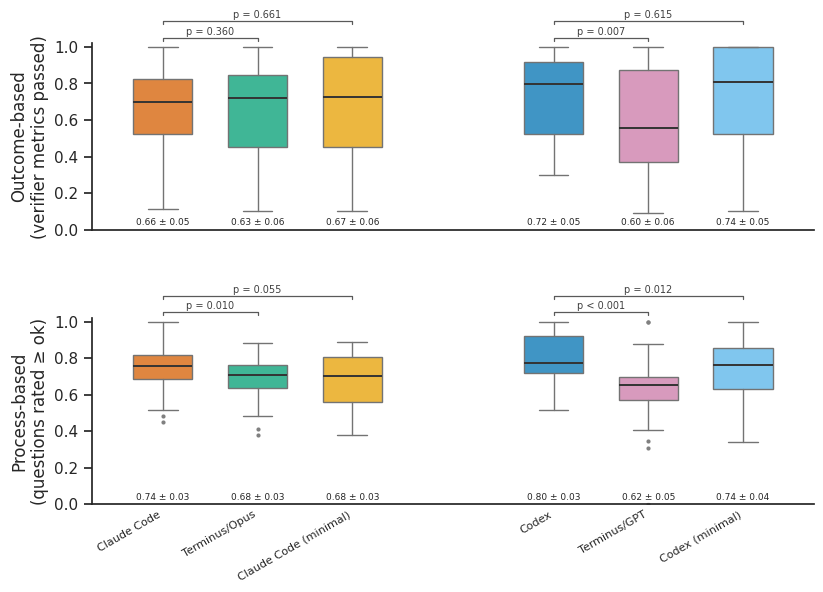

In [2]:
process = conditions.condition_scores(
    add_combined(drop_efficiency(load_condition_ratings().tidy)), rater="combined")

outcome = ot.trial_scores(ot.load(arms=ot.ALL_ARMS))
outcome = outcome[outcome.category == "Outcome"]

# Within each family: the harness swap, then the prompt cut.
TESTS = [("claude-code/full", "terminus-opus/full"),
         ("claude-code/full", "claude-code/minimal"),
         ("codex/full", "terminus-gpt/full"),
         ("codex/full", "codex/minimal")]

fig, _ = conditions.condition_boxes(
    [(f"Outcome-based\n({ot.SCORE_LABEL})", outcome, "score"),
     ("Process-based\n(questions rated \u2265 ok)", process, "frac_ok")],
    tests=TESTS, figsize=(8.4, 6.5))

fig.savefig('./compare_agents.pdf', bbox_inches='tight', dpi=300)
plt.show()